In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df = pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [ ]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [6]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [7]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [8]:
X_train , X_test , y_train , y_test = train_test_split(X , y, test_size = 0.2 , random_state=2)

In [9]:
X_test.shape,X_train.shape

((179, 3), (712, 3))

In [10]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [16]:
mean_age = X_train['Age'].mean()
median_age = X_train['Age'].median()

mean_fare = X_train['Fare'].mean()
median_fare = X_train['Fare'].median()
mean_age, median_age, mean_fare, median_fare


(np.float64(29.78590425531915),
 np.float64(28.75),
 np.float64(32.61759689349112),
 np.float64(14.4583))

In [13]:
X_train['Age_mean']= X_train['Age'].fillna(mean_age)
X_train['Age_median'] = X_train['Age'].fillna(median_age)

X_train['Fare_mean'] = X_train['Fare'].fillna(mean_fare)
X_train['Fare_median'] = X_train['Fare'].fillna(median_fare)

In [15]:
X_train.sample(5)

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
199,24.0,13.0000,0,24.000000,24.00,13.0000,13.0000
415,NaN,8.0500,0,29.785904,28.75,8.0500,8.0500
276,45.0,7.7500,0,45.000000,45.00,7.7500,7.7500
138,16.0,9.2167,0,16.000000,16.00,9.2167,9.2167
706,45.0,13.5000,0,45.000000,45.00,13.5000,13.5000


In [18]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age variance after median imputation: ',X_train['Age_median'].var())
print('Age variance after mean imputation: ',X_train['Age_mean'].var())

Original Age variable variance:  204.34951339046142
Age variance after median imputation:  161.98956633460548
Age variance after mean imputation:  161.81262452718676


In [19]:
print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare variance after median imputation: ',X_train['Fare_median'].var())
print('Fare variance after mean imputation: ',X_train['Fare_mean'].var())

Original Fare variable variance:  2448.1979137063163
Fare variance after median imputation:  2340.09102197536
Fare variance after mean imputation:  2324.2385256705534


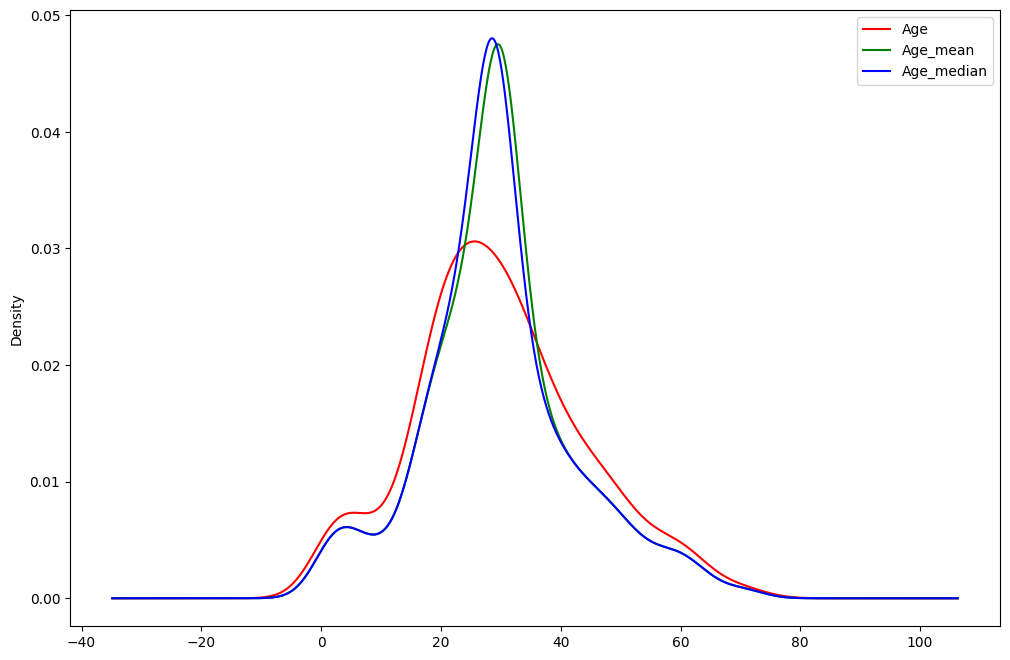

In [23]:
fig = plt.figure(figsize = (12,8))
ax= fig.add_subplot(111)

X_train['Age'].plot(kind = 'kde',ax =ax , color = 'red')
X_train['Age_mean'].plot(kind = 'kde',ax =ax , color = 'green')
X_train['Age_median'].plot(kind = 'kde',ax =ax , color = 'blue')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines ,labels,loc='best')

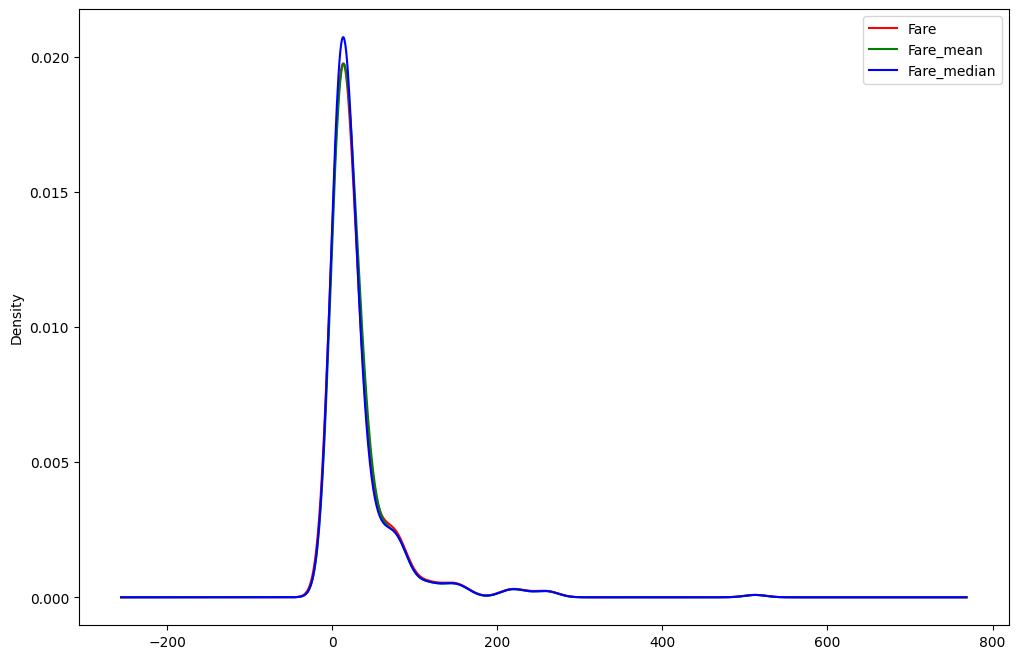

In [24]:
fig = plt.figure(figsize = (12,8))
ax= fig.add_subplot(111)

X_train['Fare'].plot(kind = 'kde',ax =ax , color = 'red')
X_train['Fare_mean'].plot(kind = 'kde',ax =ax , color = 'green')
X_train['Fare_median'].plot(kind = 'kde',ax =ax , color = 'blue')

lines, labels = ax.get_legend_handles_labels()
ax.legend(lines ,labels,loc='best')

In [25]:
X_train.cov()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,64.858859
Fare,70.719262,2448.197914,17.258917,55.603719,57.957599,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.146106,-5.112563,16.385048,16.476305
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,51.358000
Age_median,204.349513,57.957599,-5.112563,161.812625,161.989566,55.023037,53.553455
Fare_mean,66.665205,2448.197914,16.385048,52.788341,55.023037,2324.238526,2324.238526
Fare_median,64.858859,2448.197914,16.476305,51.358000,53.553455,2324.238526,2340.091022


In [26]:
X_train.corr()

,Age,Fare,Family,Age_mean,Age_median,Fare_mean,Fare_median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.090156,0.087356
Fare,0.092644,1.000000,0.208268,0.088069,0.091757,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.244610,-0.242883,0.205499,0.205942
Age_mean,1.000000,0.088069,-0.244610,1.000000,0.999454,0.086078,0.083461
Age_median,1.000000,0.091757,-0.242883,0.999454,1.000000,0.089673,0.086982
Fare_mean,0.090156,1.000000,0.205499,0.086078,0.089673,1.000000,0.996607
Fare_median,0.087356,1.000000,0.205942,0.083461,0.086982,0.996607,1.000000


<Axes: >

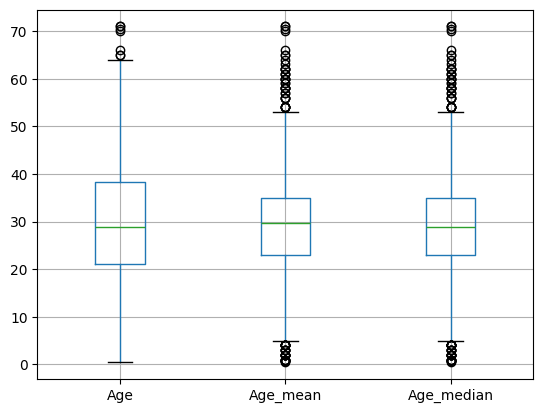

In [27]:
X_train[['Age','Age_mean','Age_median']].boxplot()

<Axes: >

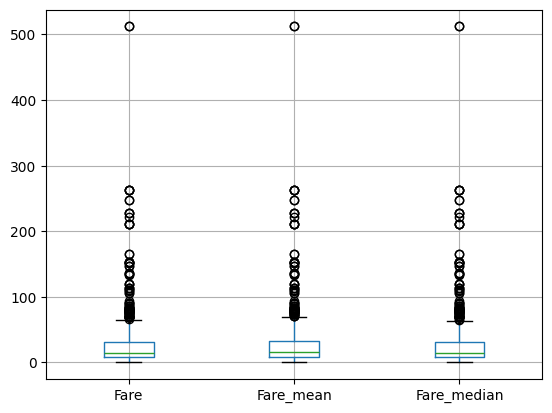

In [28]:
X_train[['Fare','Fare_mean','Fare_median']].boxplot()

# using sikitlearn

In [34]:
imputer1 = SimpleImputer(strategy='median')
imputer2 = SimpleImputer(strategy='mean')

In [35]:
trf = ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
])

In [36]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imputer1', ...), ('imputer2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name

In [37]:
trf.named_transformers_['imputer1'].statistics_


array([28.75])

In [38]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [39]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [40]:
X_train

array([[ 40.    ,  27.7208],
       [  4.    ,  16.7   ],
       [ 47.    ,   9.    ],
       ...,
       [ 71.    ,  49.5042],
       [ 28.75  , 221.7792],
       [ 28.75  ,  25.925 ]], shape=(712, 2))

In [41]:
X_train_df = pd.DataFrame(X_train, columns=['Age', 'Fare'])
X_train_df

,Age,Fare
0,40.00,27.7208
1,4.00,16.7000
2,47.00,9.0000
3,9.00,31.3875
4,20.00,9.8458
...,...,...
707,30.00,8.6625
708,28.75,8.7125
709,71.00,49.5042
710,28.75,221.7792
